# Nodal RSAM position–time heatmaps

This notebook reads the legacy serial-number-based RSAM archive, maps each
`network.station.location.channel` identifier to along-line position, merges
positions within a specified tolerance, and plots fixed-height node bands.

It generates six directly comparable heatmaps:

- T1: all vertical channels matching `*Z`
- T1: all north–south channels matching `*N`
- T1: all east–west channels matching `*E`
- T3: all vertical channels matching `*Z`
- T3: all north–south channels matching `*N`
- T3: all east–west channels matching `*E`

Channel matching uses Unix shell-style wildcard patterns through
`fnmatch.fnmatchcase()`. Thus `*Z` matches both `DPZ` and `GPZ`, while
`DP?` would match `DPZ`, `DPN`, and `DPE`.

All six plots use the same color limits. The limits are calculated from the
pooled finite values across every successfully loaded plot, using the
configured global percentiles.

In [1]:
from __future__ import annotations

from fnmatch import fnmatchcase
from pathlib import Path
from typing import Optional

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import UTCDateTime

from flovopy.processing.sam import RSAM

## Configuration

Edit this cell as needed. The `RUNS` dictionary replaces the former bash
commands. Each network has its own time interval, while the component
patterns are applied to both networks.

In [2]:
SAM_DIR = Path("/Volumes/tachyon/LBSSP_DATA/nodal_rsam")
MAPPING_CSV = Path(
    "/Volumes/tachyon/LBSSP_DATA/nodal_sds_position_codes/"
    "station_position_mapping.csv"
)
OUTPUT_DIR = SAM_DIR / "position_time_heatmaps"

RUNS = {
    "T1": {
        "start": UTCDateTime("2026-05-16T00:00:00"),
        "end": UTCDateTime("2026-05-21T00:00:00"),
    },
    "T3": {
        "start": UTCDateTime("2026-05-19T00:00:00"),
        "end": UTCDateTime("2026-05-20T00:00:00"),
    },
}

COMPONENT_PATTERNS = {
    "Z": "*Z",
    "N": "*N",
    "E": "*E",
}

SAMPLING_INTERVAL_S = 60
RSAM_EXTENSION = "csv"
METRIC = "median"
CADENCE = "1min"

POSITION_TOLERANCE_M = 0.25
NODE_HEIGHT_M = 2.0
Y_RESOLUTION_M = 1.0

USE_LOG10 = True

# Calculated once from all six pooled datasets.
GLOBAL_PERCENTILES = (2.0, 98.0)

FIGSIZE = (13, 7)
DPI = 200
VERBOSE_RSAM_READ = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"RSAM root:   {SAM_DIR}")
print(f"Mapping CSV: {MAPPING_CSV}")
print(f"Output dir:  {OUTPUT_DIR}")

RSAM root:   /Volumes/tachyon/LBSSP_DATA/nodal_rsam
Mapping CSV: /Volumes/tachyon/LBSSP_DATA/nodal_sds_position_codes/station_position_mapping.csv
Output dir:  /Volumes/tachyon/LBSSP_DATA/nodal_rsam/position_time_heatmaps


## Mapping and data preparation functions


In [3]:
def clean_seed_station(value: object) -> str:
    """Normalize a legacy five-character RSAM/SDS station code."""
    s = str(value).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s.zfill(5) if s.isdigit() else s


def serial_suffix(value: object) -> str:
    """Return the five-digit station suffix from a SmartSolo serial."""
    if pd.isna(value):
        return ""
    s = str(value).strip()
    if s.endswith(".0"):
        s = s[:-2]
    digits = "".join(ch for ch in s if ch.isdigit())
    return digits[-5:].zfill(5) if digits else ""


def load_mapping(path: Path) -> pd.DataFrame:
    """Load unique network/location/station-suffix to position mappings."""
    raw = pd.read_csv(path)

    required = {"network", "location", "x_m"}
    missing = required - set(raw.columns)
    if missing:
        raise ValueError(f"Mapping CSV lacks columns: {sorted(missing)}")

    rows: list[dict[str, object]] = []

    for _, record in raw.iterrows():
        if (
            pd.isna(record["network"])
            or pd.isna(record["location"])
            or pd.isna(record["x_m"])
        ):
            continue

        codes: set[str] = set()

        for column in ("serial", "serial_clean"):
            if column in raw.columns:
                code = serial_suffix(record.get(column))
                if code:
                    codes.add(code)

        for column in ("old_station", "old_station_clean"):
            if column in raw.columns and pd.notna(record.get(column)):
                codes.add(clean_seed_station(record[column]))

        for code in codes:
            rows.append(
                {
                    "network": str(record["network"]).strip(),
                    "location": str(record["location"]).strip(),
                    "station": code,
                    "x_m": float(record["x_m"]),
                }
            )

    mapping = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)
    if mapping.empty:
        raise ValueError("No usable station mappings were found in the CSV.")

    ambiguity = (
        mapping.groupby(["network", "location", "station"])["x_m"]
        .nunique()
        .loc[lambda values: values > 1]
    )
    if not ambiguity.empty:
        raise ValueError(
            "Ambiguous network/location/station mappings remain:\n"
            + ambiguity.to_string()
        )

    return mapping


def parse_seed_id(seed_id: str) -> tuple[str, str, str, str]:
    parts = seed_id.split(".")
    if len(parts) != 4:
        raise ValueError(f"Expected NET.STA.LOC.CHA, got {seed_id!r}")
    return tuple(parts)


def lookup_position(seed_id: str, mapping: pd.DataFrame) -> float:
    net, sta, loc, _ = parse_seed_id(seed_id)
    sta_clean = clean_seed_station(sta)

    candidates = mapping[
        (mapping["network"] == net)
        & (mapping["location"] == loc)
        & (mapping["station"] == sta_clean)
    ]

    if len(candidates) == 1:
        return float(candidates.iloc[0]["x_m"])

    if len(candidates) > 1:
        positions = sorted(candidates["x_m"].unique())
        if len(positions) == 1:
            return float(positions[0])
        raise ValueError(f"Ambiguous position for {seed_id}: {positions}")

    if mapping.empty and sta_clean.isdigit() and len(sta_clean) == 5:
        return int(sta_clean) / 100.0

    raise KeyError(f"No position mapping for {seed_id}")


def dataframe_time_series(df: pd.DataFrame, metric: str) -> pd.Series:
    if metric not in df.columns:
        raise KeyError(
            f"Metric {metric!r} not present; "
            f"available columns: {list(df.columns)}"
        )

    if isinstance(df.index, pd.DatetimeIndex):
        times = pd.to_datetime(df.index, utc=True)
    else:
        time_col = next(
            (
                column
                for column in ("time", "datetime", "date", "timestamp")
                if column in df.columns
            ),
            None,
        )

        if time_col is None:
            numeric = pd.to_numeric(pd.Index(df.index), errors="coerce")
            if np.isfinite(numeric).all():
                times = pd.to_datetime(numeric, unit="s", utc=True)
            else:
                times = pd.to_datetime(
                    df.index, utc=True, errors="coerce"
                )
        else:
            values = df[time_col]
            times = pd.to_datetime(
                values,
                unit=(
                    "s"
                    if pd.api.types.is_numeric_dtype(values)
                    else None
                ),
                utc=True,
                errors="coerce",
            )

    values = pd.to_numeric(df[metric], errors="coerce").to_numpy()
    series = pd.Series(values, index=times)
    return series[~series.index.isna()].sort_index()


def cluster_positions(
    values: pd.Series,
    tolerance_m: float,
) -> tuple[pd.Series, pd.DataFrame]:
    """Collapse positions into groups whose total span is <= tolerance."""
    unique = np.sort(values.dropna().unique().astype(float))
    if not len(unique):
        return values.copy(), pd.DataFrame()

    clusters: list[list[float]] = []
    current = [float(unique[0])]

    for x in unique[1:]:
        x = float(x)
        if x - current[0] <= tolerance_m + 1e-12:
            current.append(x)
        else:
            clusters.append(current)
            current = [x]

    clusters.append(current)

    lookup: dict[float, float] = {}
    summary_rows: list[dict[str, object]] = []

    for cluster_id, members in enumerate(clusters, start=1):
        mean_x = float(np.mean(members))

        for x in members:
            lookup[x] = mean_x

        summary_rows.append(
            {
                "cluster": cluster_id,
                "mean_x_m": mean_x,
                "min_x_m": min(members),
                "max_x_m": max(members),
                "n_original_positions": len(members),
            }
        )

    clustered = values.map(
        lambda x: (
            lookup.get(float(x), np.nan)
            if pd.notna(x)
            else np.nan
        )
    )

    return clustered, pd.DataFrame(summary_rows)


def build_long_table(
    rsam: RSAM,
    mapping: pd.DataFrame,
    metric: str,
    channel_pattern: str,
    position_tolerance_m: float,
) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """Build one long table for channels matching channel_pattern."""
    rows: list[pd.DataFrame] = []
    skipped: list[tuple[str, str]] = []
    matched_seed_ids: list[str] = []

    for seed_id, df in rsam.dataframes.items():
        try:
            net, sta, loc, cha = parse_seed_id(seed_id)

            if not fnmatchcase(cha, channel_pattern):
                continue

            position = lookup_position(seed_id, mapping)
            series = dataframe_time_series(df, metric)

        except Exception as exc:
            skipped.append((seed_id, str(exc)))
            continue

        good = np.isfinite(series.to_numpy(dtype=float))
        if not good.any():
            continue

        matched_seed_ids.append(seed_id)

        rows.append(
            pd.DataFrame(
                {
                    "time": series.index[good],
                    "value": series.to_numpy(dtype=float)[good],
                    "network": net,
                    "station": sta,
                    "location": loc,
                    "channel": cha,
                    "x_m_original": position,
                    "seed_id": seed_id,
                }
            )
        )

    if skipped:
        print(f"Skipped {len(skipped)} trace IDs. First examples:")
        for seed_id, reason in skipped[:15]:
            print(f"  {seed_id}: {reason}")

    if not rows:
        raise RuntimeError(
            "No mapped RSAM samples remained after filtering with "
            f"channel pattern {channel_pattern!r}."
        )

    table = pd.concat(rows, ignore_index=True)
    table["x_m"], clusters = cluster_positions(
        table["x_m_original"],
        position_tolerance_m,
    )

    return table, clusters, sorted(matched_seed_ids)

## Grid and plotting functions


In [4]:
def make_grid(
    table: pd.DataFrame,
    cadence: str,
) -> tuple[pd.DatetimeIndex, np.ndarray, np.ndarray]:
    """Create one resampled time series per merged physical position."""
    positions = np.sort(table["x_m"].dropna().unique())

    t0 = table["time"].min().floor(cadence)
    t1 = table["time"].max().ceil(cadence)
    times = pd.date_range(t0, t1, freq=cadence, tz="UTC")

    grid = np.full((len(positions), len(times)), np.nan)

    for i, x_m in enumerate(positions):
        series = (
            table.loc[table["x_m"] == x_m]
            .set_index("time")["value"]
            .sort_index()
            .resample(cadence)
            .median()
            .reindex(times)
        )
        grid[i, :] = series.to_numpy(dtype=float)

    return times, positions, grid


def make_fixed_height_position_grid(
    positions: np.ndarray,
    grid: np.ndarray,
    *,
    node_height_m: float = 2.0,
    y_resolution_m: float = 1.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Expand each node series into a fixed-height vertical band."""
    if node_height_m <= 0:
        raise ValueError("node_height_m must be positive.")
    if y_resolution_m <= 0:
        raise ValueError("y_resolution_m must be positive.")

    display_positions = np.rint(positions).astype(int)

    duplicates = pd.Series(display_positions).value_counts()
    duplicates = duplicates[duplicates > 1]

    if not duplicates.empty:
        details: list[str] = []

        for rounded_position in duplicates.index:
            original = positions[
                display_positions == rounded_position
            ]
            details.append(
                f"{rounded_position} m <- "
                + ", ".join(f"{x:.3f} m" for x in original)
            )

        raise ValueError(
            "Rounding clustered positions to whole metres merged "
            "distinct nodes:\n"
            + "\n".join(details)
        )

    half_height = node_height_m / 2.0

    y_min = np.floor(display_positions.min() - half_height)
    y_max = np.ceil(display_positions.max() + half_height)

    y_edges = np.arange(
        y_min,
        y_max + y_resolution_m,
        y_resolution_m,
        dtype=float,
    )

    y_lower = y_edges[:-1]
    y_upper = y_edges[1:]

    expanded = np.full(
        (len(y_edges) - 1, grid.shape[1]),
        np.nan,
        dtype=float,
    )

    for source_row, position in enumerate(display_positions):
        band_min = position - half_height
        band_max = position + half_height

        target_rows = (
            (y_lower >= band_min - 1e-9)
            & (y_upper <= band_max + 1e-9)
        )

        expanded[target_rows, :] = grid[source_row, :]

    return display_positions, y_edges, expanded


def datetime_bin_edges(
    times: pd.DatetimeIndex,
    cadence: str,
) -> np.ndarray:
    """Construct explicit left-aligned time-bin edges."""
    if len(times) == 0:
        raise ValueError("No times supplied.")

    delta = pd.to_timedelta(cadence)
    edges = times.append(
        pd.DatetimeIndex([times[-1] + delta])
    )

    return mdates.date2num(edges.to_pydatetime())


def transform_grid(
    display_grid: np.ndarray,
    use_log10: bool,
) -> np.ndarray:
    """Apply the chosen amplitude transform and mask invalid values."""
    if use_log10:
        with np.errstate(divide="ignore", invalid="ignore"):
            z = np.log10(display_grid)
    else:
        z = display_grid.copy()

    z[~np.isfinite(z)] = np.nan
    return z


def prepare_plot_data(
    table: pd.DataFrame,
    *,
    cadence: str,
    node_height_m: float,
    y_resolution_m: float,
    use_log10: bool,
) -> dict[str, object]:
    times, physical_positions, node_grid = make_grid(
        table,
        cadence,
    )

    display_positions, y_edges, display_grid = (
        make_fixed_height_position_grid(
            physical_positions,
            node_grid,
            node_height_m=node_height_m,
            y_resolution_m=y_resolution_m,
        )
    )

    z = transform_grid(display_grid, use_log10)

    if not np.isfinite(z).any():
        raise RuntimeError("No finite values available for plotting.")

    return {
        "times": times,
        "physical_positions": physical_positions,
        "display_positions": display_positions,
        "y_edges": y_edges,
        "z": z,
    }


def plot_heatmap(
    plot_data: dict[str, object],
    *,
    outfile: Path,
    title: str,
    metric: str,
    cadence: str,
    use_log10: bool,
    vmin: float,
    vmax: float,
    figsize: tuple[float, float] = (13, 7),
    dpi: int = 200,
) -> tuple[plt.Figure, plt.Axes]:
    times = plot_data["times"]
    display_positions = plot_data["display_positions"]
    y_edges = plot_data["y_edges"]
    z = plot_data["z"]

    x_edges = datetime_bin_edges(times, cadence)

    fig, ax = plt.subplots(
        figsize=figsize,
        constrained_layout=True,
    )

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        z,
        shading="flat",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_ylabel("Position along profile (m)")
    ax.set_xlabel("Time (UTC)")
    ax.set_ylim(y_edges[0], y_edges[-1])

    locator = mdates.AutoDateLocator(minticks=5, maxticks=9)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(locator)
    )

    if len(display_positions) <= 50:
        ax.set_yticks(display_positions)

    ax.grid(False)

    cbar = fig.colorbar(mesh, ax=ax, pad=0.015)
    cbar.set_label(
        f"log10({metric})" if use_log10 else metric
    )

    ax.set_title(title)

    outfile.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(outfile, dpi=dpi, bbox_inches="tight")
    print(f"Wrote {outfile}")

    return fig, ax

## Load mapping and RSAM archives

RSAM is loaded once per network and reused for all three component patterns.

In [5]:
mapping = load_mapping(MAPPING_CSV)
print(
    f"Loaded {len(mapping)} unique "
    "network/location/station mappings."
)

rsam_by_network: dict[str, RSAM] = {}

for network, time_window in RUNS.items():
    print(
        f"\nReading {network}: "
        f"{time_window['start']} to {time_window['end']}"
    )

    rsam_by_network[network] = RSAM.read(
        time_window["start"],
        time_window["end"],
        SAM_DIR=str(SAM_DIR),
        network=network,
        sampling_interval=SAMPLING_INTERVAL_S,
        ext=RSAM_EXTENSION,
        verbose=VERBOSE_RSAM_READ,
    )

    print(
        f"  Loaded "
        f"{len(rsam_by_network[network].dataframes)} "
        "RSAM trace dataframes."
    )

Loaded 143 unique network/location/station mappings.

Reading T1: 2026-05-16T00:00:00.000000Z to 2026-05-21T00:00:00.000000Z
Dataframe with 1411 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1411 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1411 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 2720 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 2720 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 2720 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 60 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 60 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 60 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1437 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1437 rows is already on a regular 60 s grid ba

## Build all six datasets

Multiple channels at the same merged position and time are combined by the
median during gridding. This means, for example, that `DPZ` and `GPZ` both
contribute when the pattern is `*Z`.

In [6]:
results: dict[tuple[str, str], dict[str, object]] = {}

for network, rsam in rsam_by_network.items():
    for component, channel_pattern in COMPONENT_PATTERNS.items():
        key = (network, component)

        print(
            f"\nPreparing {network} {component}: "
            f"channel pattern {channel_pattern!r}"
        )

        try:
            table, clusters, matched_seed_ids = build_long_table(
                rsam=rsam,
                mapping=mapping,
                metric=METRIC,
                channel_pattern=channel_pattern,
                position_tolerance_m=POSITION_TOLERANCE_M,
            )

            plot_data = prepare_plot_data(
                table,
                cadence=CADENCE,
                node_height_m=NODE_HEIGHT_M,
                y_resolution_m=Y_RESOLUTION_M,
                use_log10=USE_LOG10,
            )

        except RuntimeError as exc:
            print(f"  Skipping {network} {component}: {exc}")
            continue

        matched_channels = sorted(table["channel"].unique())

        print(
            f"  Matched {len(matched_seed_ids)} seed IDs; "
            f"channels: {matched_channels}"
        )
        print(
            f"  Merged positions: "
            f"{table['x_m'].nunique()}"
        )

        results[key] = {
            "table": table,
            "clusters": clusters,
            "matched_seed_ids": matched_seed_ids,
            "matched_channels": matched_channels,
            "plot_data": plot_data,
            "channel_pattern": channel_pattern,
        }

if not results:
    raise RuntimeError("None of the requested datasets could be prepared.")

print(f"\nPrepared {len(results)} plot datasets.")


Preparing T1 Z: channel pattern '*Z'
  Matched 72 seed IDs; channels: ['DPZ']
  Merged positions: 31

Preparing T1 N: channel pattern '*N'
  Matched 72 seed IDs; channels: ['DPN']
  Merged positions: 31

Preparing T1 E: channel pattern '*E'
  Matched 72 seed IDs; channels: ['DPE']
  Merged positions: 31

Preparing T3 Z: channel pattern '*Z'
  Skipping T3 Z: No mapped RSAM samples remained after filtering with channel pattern '*Z'.

Preparing T3 N: channel pattern '*N'
  Skipping T3 N: No mapped RSAM samples remained after filtering with channel pattern '*N'.

Preparing T3 E: channel pattern '*E'
  Skipping T3 E: No mapped RSAM samples remained after filtering with channel pattern '*E'.

Prepared 3 plot datasets.


## Calculate shared color limits

The percentile calculation pools every finite transformed pixel from all
successfully prepared network/component datasets. These exact limits are then
supplied to every plot.

In [7]:
pooled_values = np.concatenate(
    [
        result["plot_data"]["z"][
            np.isfinite(result["plot_data"]["z"])
        ]
        for result in results.values()
    ]
)

GLOBAL_VMIN, GLOBAL_VMAX = np.nanpercentile(
    pooled_values,
    GLOBAL_PERCENTILES,
)

print(
    f"Shared color limits from pooled "
    f"{GLOBAL_PERCENTILES[0]:g}–{GLOBAL_PERCENTILES[1]:g} "
    f"percentiles:"
)
print(f"  vmin = {GLOBAL_VMIN:.6g}")
print(f"  vmax = {GLOBAL_VMAX:.6g}")
print(f"  finite pooled values = {pooled_values.size:,}")

Shared color limits from pooled 2–98 percentiles:
  vmin = -3.05161
  vmax = -1.03246
  finite pooled values = 596,274


## Generate and save all individual heatmaps


Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam/position_time_heatmaps/T1_rsam_position_time_Z.png


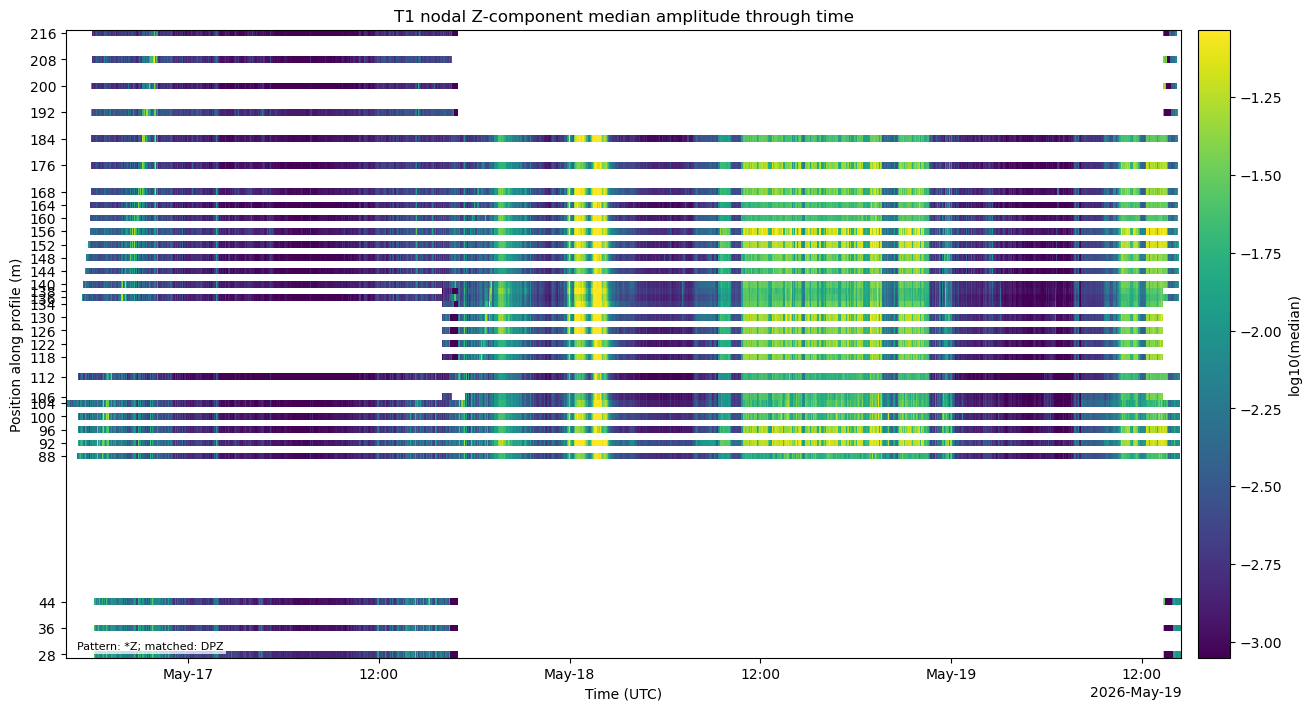

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam/position_time_heatmaps/T1_rsam_position_time_N.png


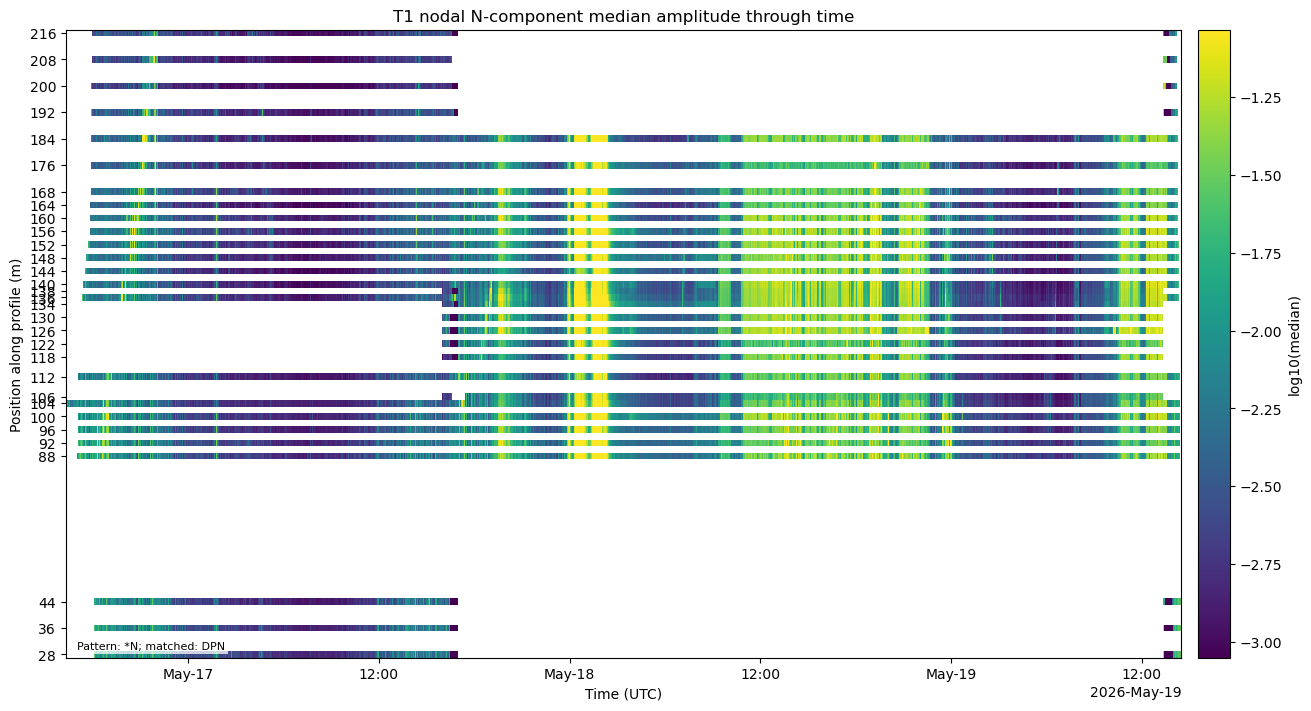

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_rsam/position_time_heatmaps/T1_rsam_position_time_E.png


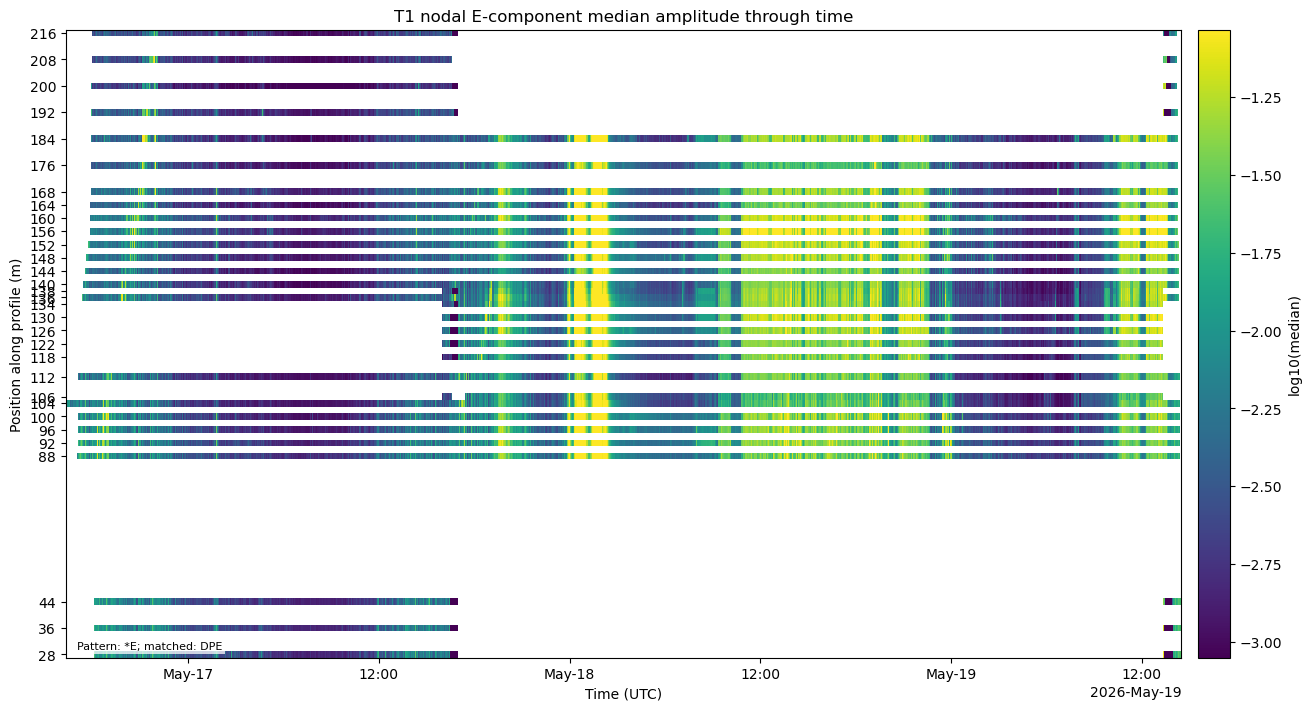

In [8]:
figures: dict[tuple[str, str], tuple[plt.Figure, plt.Axes]] = {}

for network in RUNS:
    for component in COMPONENT_PATTERNS:
        key = (network, component)

        if key not in results:
            continue

        channel_pattern = results[key]["channel_pattern"]
        matched_channels = ", ".join(
            results[key]["matched_channels"]
        )

        outfile = (
            OUTPUT_DIR
            / f"{network}_rsam_position_time_{component}.png"
        )

        title = (
            f"{network} nodal {component}-component "
            f"{METRIC} amplitude through time"
        )

        fig, ax = plot_heatmap(
            results[key]["plot_data"],
            outfile=outfile,
            title=title,
            metric=METRIC,
            cadence=CADENCE,
            use_log10=USE_LOG10,
            vmin=GLOBAL_VMIN,
            vmax=GLOBAL_VMAX,
            figsize=FIGSIZE,
            dpi=DPI,
        )

        ax.text(
            0.01,
            0.01,
            (
                f"Pattern: {channel_pattern}; "
                f"matched: {matched_channels}"
            ),
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=8,
            bbox={
                "facecolor": "white",
                "alpha": 0.75,
                "edgecolor": "none",
                "pad": 2,
            },
        )

        # Save again after adding the matched-channel annotation.
        fig.savefig(outfile, dpi=DPI, bbox_inches="tight")

        figures[key] = (fig, ax)
        plt.show()

## QC summary

This table records which channel codes were actually matched and how many
positions and samples entered each plot.

In [9]:
summary_rows = []

for (network, component), result in results.items():
    table = result["table"]

    summary_rows.append(
        {
            "network": network,
            "component": component,
            "channel_pattern": result["channel_pattern"],
            "matched_channels": ", ".join(
                result["matched_channels"]
            ),
            "seed_ids": len(result["matched_seed_ids"]),
            "merged_positions": table["x_m"].nunique(),
            "samples": len(table),
            "global_vmin": GLOBAL_VMIN,
            "global_vmax": GLOBAL_VMAX,
        }
    )

summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["network", "component"])
    .reset_index(drop=True)
)

summary

,network,component,channel_pattern,matched_channels,seed_ids,merged_positions,samples,global_vmin,global_vmax
0,T1,E,*E,DPE,72,31,100399,-3.051614,-1.032458
1,T1,N,*N,DPN,72,31,100399,-3.051614,-1.032458
2,T1,Z,*Z,DPZ,72,31,100399,-3.051614,-1.032458


## Optional: inspect position clustering for one dataset

Change `QC_KEY` to any successfully prepared `(network, component)` pair.

In [10]:
QC_KEY = ("T1", "Z")

if QC_KEY in results:
    display(results[QC_KEY]["clusters"])
else:
    print(f"{QC_KEY} was not prepared.")

,cluster,mean_x_m,min_x_m,max_x_m,n_original_positions
0,1,28.000,28.000,28.000,1
1,2,36.000,36.000,36.000,1
2,3,44.000,44.000,44.000,1
3,4,88.075,88.075,88.075,1
4,5,92.100,92.100,92.100,1
5,6,96.050,96.050,96.050,1
6,7,100.000,100.000,100.000,1
7,8,104.030,103.980,104.080,2
8,9,106.030,106.030,106.030,1
9,10,112.085,112.020,112.150,2
